# Statistiques Word Structure sur le S4 Platinum

In [2]:
import re,codecs,yaml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def ding():
    os.system('afplay /System/Library/Sounds/Submarine.aiff')

%store -r ordStemCells

In [3]:
sns.set_style("whitegrid")

In [48]:
tenseLabels=["Infinitive","Present participle","Past participle",
             "Indicative present","Imperative","Subjunctive present",
             "Imperfective","Future","Conditional",
             "Simple past","Subjunctive imperfective"]

In [4]:
repFiles="/Users/gilles/sDrive/Recherche/Boye/HDR/Data/vlexique2.0.3/WordStructure/"

# Étude S4 Platinum

In [5]:
cellOrd=['inf', 'pP', 'ppMS', 'ppMP', 'ppFS', 'ppFP', 'pi1S', 'pi2S', 'pi3S', 'pi1P', 'pi2P', 'pi3P', 'pI2S', 'pI1P', 'pI2P', 'ps1S', 'ps2S', 'ps3S', 'ps1P', 'ps2P', 'ps3P', 'ii1S', 'ii2S', 'ii3S', 'ii1P', 'ii2P', 'ii3P', 'fi1S', 'fi2S', 'fi3S', 'fi1P', 'fi2P', 'fi3P', 'pc1S', 'pc2S', 'pc3S', 'pc1P', 'pc2P', 'pc3P', 'ai1S', 'ai2S', 'ai3S', 'ai1P', 'ai2P', 'ai3P', 'is1S', 'is2S', 'is3S', 'is1P', 'is2P', 'is3P']

dColors={}
for c in cellOrd:
    if cellOrd.index(c)<21:
        dColors[c]="green"
    elif cellOrd.index(c)>38:
        dColors[c]="red"
    else:
        dColors[c]="orange"

cellColor=[dColors[c] for c in cellOrd]
cellGreen=[c for c,x in dColors.items() if x=="green"]
cellRed=[c for c,x in dColors.items() if x=="red"]
cellOrange=[c for c,x in dColors.items() if x=="orange"]

## Graphes Précision Rappel 

In [6]:
dTiroir={"in":"Infinitif","pP":"Participe présent",
         "pp":"Participe passé","pi":"Indicatif présent",
         "pI":"Impératif","ps":"Subjonctif présent",
         "ii":"Imparfait","fi":"Futur","pc":"Conditionnel",
         "ai":"Passé simple","is":"Subjonctif imparfait"}
dNbTiroir={"Infinitif":1, "Participe présent":1, "Participe passé":4, "Indicatif présent":6, "Impératif":3, "Subjonctif présent":6, "Imparfait":6, "Futur":6, "Conditionnel":6, "Passé simple":6, "Subjonctif imparfait":6}
lTiroir=list(dTiroir.values())

def makeSubparadigmTable(df):
    dfT=df.T
    dfT["Subparadigm"]=dfT.index.str[:2]
    dfT["Subparadigm"]=dfT.Subparadigm.replace(dTiroir)
    return dfT.groupby("Subparadigm").count().T.sum()

### Input

In [7]:
fInput4=repFiles+"vlexique2-S4.csv"
dfInput4=pd.read_csv(fInput4,sep=";")
dfInput4.set_index("lexeme",inplace=True)
ixInput4=dfInput4.index
dfInput4

,ai1P,ai1S,ai2P,ai2S,ai3P,ai3S,fi1P,fi1S,fi2P,fi2S,...,ppFP,ppFS,ppMP,ppMS,ps1P,ps1S,ps2P,ps2S,ps3P,ps3S
lexeme,,,,,,,,,,,,,,,,,,,,,
abaisser,NaN,NaN,NaN,NaN,NaN,NaN,NaN,abEs6rE,NaN,NaN,...,abEse,abEse,abEse,abEse,NaN,abEs,NaN,abEs,NaN,abEs
abandonner,NaN,abâdOnE,NaN,NaN,abâdOnEr,abâdOna,abâdOn6rô,abâdOn6rE,abâdOn6re,abâdOn6ra,...,abâdOne,abâdOne,abâdOne,abâdOne,abâdOnjô,abâdOn,abâdOnje,abâdOn,abâdOn,abâdOn
abasourdir,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,abazurdi,abazurdi,abazurdi,NaN,NaN,NaN,NaN,NaN,NaN
abattre,NaN,NaN,NaN,NaN,abatir,abati,abatrô,abatrE,abatre,abatra,...,abaty,abaty,abaty,abaty,NaN,abat,abatje,abat,abat,abat
abdiquer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,abdike,NaN,NaN,NaN,NaN,NaN,abdik
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
éviscérer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,EvisEre,EvisEre,EvisEre,NaN,NaN,NaN,NaN,NaN,NaN
éviter,NaN,NaN,NaN,NaN,NaN,Evita,Evit6rô,Evit6rE,Evit6re,Evit6ra,...,Evite,Evite,Evite,Evite,Evitjô,Evit,Evitje,Evit,Evit,Evit
évoluer,NaN,NaN,NaN,NaN,NaN,EvOlHa,NaN,NaN,NaN,EvOlyra,...,EvOlHe,EvOlHe,EvOlHe,EvOlHe,NaN,NaN,NaN,NaN,EvOly,EvOly


In [8]:
def getTable(fName):
    df=pd.read_csv(fName,sep=";")
    if "Unnamed: 0" in df.columns:
        df.set_index("Unnamed: 0",inplace=True)
        df.index.rename("lexeme",inplace=True)
    elif "lexeme" in df.columns:
        df.set_index("lexeme",inplace=True)
    for c in cellOrd:
        if c not in df.columns:
            df[c]=np.NaN
    return df[cellOrd]

In [9]:
fDirect4Diff=repFiles+"vlexique2-Direct-S4-omp-platinum-different.csv"
fDirect4Corr=repFiles+"vlexique2-Direct-S4-omp-platinum-correct.csv"
fDirect4Miss=repFiles+"vlexique2-Direct-S4-omp-platinum-missing.csv"

dfDirect4Diff=getTable(fDirect4Diff)
dfDirect4Corr=getTable(fDirect4Corr)
dfDirect4Miss=getTable(fDirect4Miss)


In [24]:
dfInput4T=makeSubparadigmTable(dfInput4)
dfDirect4CorrT=makeSubparadigmTable(dfDirect4Corr)
dfDirect4DiffT=makeSubparadigmTable(dfDirect4Diff)
dfDirect4MissT=makeSubparadigmTable(dfDirect4Miss)
dfDirect4KRWM=pd.DataFrame({"known":dfInput4T,
              "correct":dfDirect4CorrT,
              "wrong":dfDirect4DiffT,
              "missing":dfDirect4MissT}).reindex(lTiroir)
dfDirect4KRWM["errors"]=dfDirect4KRWM.wrong+dfDirect4KRWM.missing
dfDirect4KRWM["recall"]=round(dfDirect4KRWM.correct/(dfDirect4KRWM.correct+dfDirect4KRWM.wrong+dfDirect4KRWM.missing)*100,1).astype(str)+"%"
dfDirect4KRWM["pErrors"]=round(dfDirect4KRWM.errors/(dfDirect4KRWM.correct+dfDirect4KRWM.errors)*100,1).astype(str)+"%"
dfDirect4KRWM

,known,correct,wrong,missing,errors,recall,pErrors
Subparadigm,,,,,,,
Infinitif,3955,272,14,2,16,94.4%,5.6%
Participe présent,1875,2316,44,3,47,98.0%,2.0%
Participe passé,9990,6839,111,4,115,98.3%,1.7%
Indicatif présent,12289,12885,213,10,223,98.3%,1.7%
Impératif,4476,8076,126,11,137,98.3%,1.7%
Subjonctif présent,4913,19773,612,102,714,96.5%,3.5%
Imparfait,5486,19289,489,112,601,97.0%,3.0%
Futur,5801,19156,543,51,594,97.0%,3.0%
Conditionnel,3198,21503,761,96,857,96.2%,3.8%


In [92]:
dfDirect4KRWM.iloc[:9]

,known,correct,wrong,missing,errors,recall,pErrors
Subparadigm,,,,,,,
Infinitif,3955,272,14,2,16,94.4%,5.6%
Participe présent,1875,2316,44,3,47,98.0%,2.0%
Participe passé,9990,6839,111,4,115,98.3%,1.7%
Indicatif présent,12289,12885,213,10,223,98.3%,1.7%
Impératif,4476,8076,126,11,137,98.3%,1.7%
Subjonctif présent,4913,19773,612,102,714,96.5%,3.5%
Imparfait,5486,19289,489,112,601,97.0%,3.0%
Futur,5801,19156,543,51,594,97.0%,3.0%
Conditionnel,3198,21503,761,96,857,96.2%,3.8%


0 5.6% 3955.0 272.0 8.0
1 2.0% 1875.0 2316.0 23.5
2 1.7% 9990.0 6839.0 57.5
3 1.7% 12289.0 12885.0 111.5
4 1.7% 4476.0 8076.0 68.5
5 3.5% 4913.0 19773.0 357.0
6 3.0% 5486.0 19289.0 300.5
7 3.0% 5801.0 19156.0 297.0
8 3.8% 3198.0 21503.0 428.5
9 31.3% 1449.0 16403.0 3735.0
10 91.2% 53.0 2221.0 11518.5


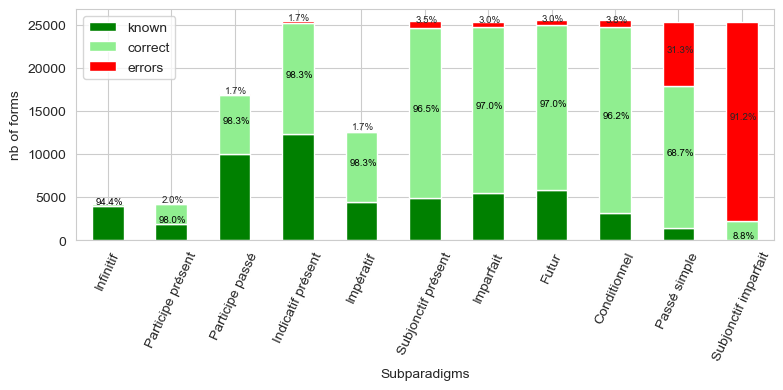

In [55]:
ax=dfDirect4KRWM[["known","correct","errors"]].plot.bar(stacked=True,figsize=(9,3),color=["green","lightgreen","red"])
ax.set_xlabel("Subparadigms")
ax.set_ylabel("nb of forms")
ax.tick_params(axis='x', labelrotation=65)
labels=["known","correct","errors"]
plt.legend(labels);

errLabels=dfDirect4KRWM["recall"].tolist()
absLabels=dfDirect4KRWM["pErrors"].tolist()

rects=ax.patches
heights0=[]
for rect in rects[:11]:
    heights0.append(rect.get_height())

nHeights0=0
heights1=[]
for rect, label in zip(rects[11:22], errLabels):
    height=rect.get_height()
    if height<2500:
        height=0
    ax.text(rect.get_x()+rect.get_width()/2+0.025, 
            height/2+heights0[nHeights0], 
            label,         
            ha="center", va="bottom", 
            fontsize=7,rotation=0,color="black",
    )
    nHeights0+=1
    height=rect.get_height()
    heights1.append(height)
    
nHeights1=0
for rect, label in zip(rects[22:], absLabels):
    print(nHeights1,label,heights0[nHeights1],heights1[nHeights1],rect.get_height()/2)
    if nHeights1!=0:
        height=heights0[nHeights1]+heights1[nHeights1]+rect.get_height()/2
        ax.text(
            rect.get_x()+rect.get_width()/2+0.025, height, label, 
            ha="center", va="bottom", fontsize=7,rotation=0
        )
    nHeights1+=1
    
plt.savefig(repFiles+"Recall-Platinum-FormsTenses.png",dpi=300,bbox_inches="tight")

In [22]:
dfGP=pd.read_csv("Temp-Gold.csv")
dfGP.set_index("Subparadigm",inplace=True)
dfGP["errorsG"]=dfGP.wrongG+dfGP.missingG
dfGP["errorsN"]=dfGP.wrongN+dfGP.missingN
dfGP

,known,correctG,wrongG,missingG,totalG,correctP,wrongP,missingP,correctN,wrongN,missingN,totalN,pTotalG,pTotalN,errorsG,errorsN
Subparadigm,,,,,,,,,,,,,,,,
Infinitif,3955,240,12,0,252,272,14,2,32,2,2,36,87.5%,12.5%,12,4
Participe présent,1875,1522,23,1,1546,2316,44,3,794,21,2,817,65.4%,34.6%,24,23
Participe passé,9990,4115,57,2,4174,6839,111,4,2724,54,2,2780,60.0%,40.0%,59,56
Indicatif présent,12289,7814,107,2,7923,12885,213,10,5071,106,8,5185,60.4%,39.6%,109,114
Impératif,4476,4261,51,6,4318,8076,126,11,3815,75,5,3895,52.6%,47.4%,57,80
Subjonctif présent,4913,7614,150,2,7766,19773,612,102,12159,462,100,12721,37.9%,62.1%,152,562
Imparfait,5486,7697,91,7,7795,19289,489,112,11592,398,105,12095,39.2%,60.8%,98,503
Futur,5801,7903,198,12,8113,19156,543,51,11253,345,39,11637,41.1%,58.9%,210,384
Conditionnel,3198,6361,154,4,6519,21503,761,96,15142,607,92,15841,29.2%,70.8%,158,699


0 12.5% 3955.0 252.0 18.0
1 34.6% 1875.0 1546.0 408.5
2 40.0% 9990.0 4174.0 1390.0
3 39.6% 12289.0 7923.0 2592.5
4 47.4% 4476.0 4318.0 1947.5
5 62.1% 4913.0 7766.0 6360.5
6 60.8% 5486.0 7795.0 6047.5
7 58.9% 5801.0 8113.0 5818.5
8 70.8% 3198.0 6519.0 7920.5
9 84.2% 1449.0 3760.0 10056.5
10 98.0% 53.0 507.0 12375.5


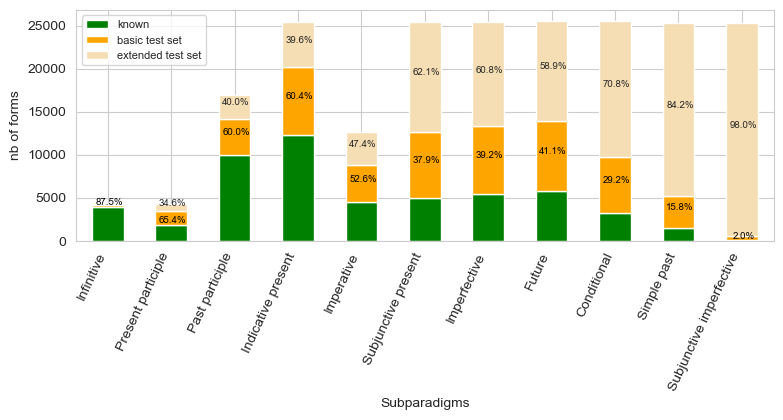

In [54]:
ax=dfGP[["known","totalG","totalN"]].plot.bar(stacked=True,figsize=(9,3),color=["green","orange","wheat"])
ax.set_xlabel("Subparadigms")
ax.set_ylabel("nb of forms")
ax.set_xticklabels(tenseLabels,rotation=65,ha="right")
labels=["known","basic test set","extended test set"]
plt.legend(labels, fontsize=8);

errLabels=dfGP["pTotalG"].tolist()
absLabels=dfGP["pTotalN"].tolist()

rects=ax.patches
heights0=[]
for rect in rects[:11]:
    heights0.append(rect.get_height())

nHeights0=0
heights1=[]
for rect, label in zip(rects[11:22], errLabels):
    height=rect.get_height()
    if height<2500:
        height=0
    ax.text(rect.get_x()+rect.get_width()/2+0.025, 
            height/2+heights0[nHeights0], 
            label,         
            ha="center", va="bottom", 
            fontsize=7,rotation=0,color="black",
    )
    nHeights0+=1
    height=rect.get_height()
    heights1.append(height)
    
nHeights1=0
for rect, label in zip(rects[22:], absLabels):
    print(nHeights1,label,heights0[nHeights1],heights1[nHeights1],rect.get_height()/2)
    if nHeights1!=0:
        height=heights0[nHeights1]+heights1[nHeights1]+rect.get_height()/2
        ax.text(
            rect.get_x()+rect.get_width()/2+0.025, height, label, 
            ha="center", va="bottom", fontsize=7,rotation=0
        )
    nHeights1+=1

plt.savefig(repFiles+"Extended-Platinum-FormsTenses.png",dpi=300,bbox_inches="tight")

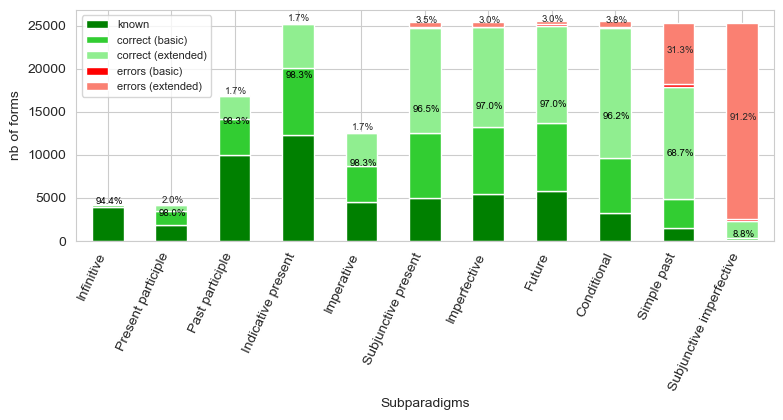

In [55]:
ax=dfGP[["known","correctG","correctN","errorsG","errorsN"]].plot.bar(stacked=True,figsize=(9,3),color=["green","limegreen","lightgreen","red","salmon"])
ax.set_xlabel("Subparadigms")
ax.set_ylabel("nb of forms")
ax.set_xticklabels(tenseLabels,rotation=65,ha="right")
labels=["known","correct (basic)","correct (extended)","errors (basic)","errors (extended)"]
plt.legend(labels, fontsize=8);

recLabels=dfDirect4KRWM["recall"].tolist()
errLabels=dfDirect4KRWM["pErrors"].tolist()

rects=ax.patches
heights0=[]
for rect in rects[:11]:
    heights0.append(rect.get_height())

heights1=[]
for rect in rects[11:22]:
    heights1.append(rect.get_height())

heights2=[]
for rect in rects[22:33]:
    heights2.append(rect.get_height())

nHeights0=0
for rect, label in zip(rects[22:33], recLabels):
    height=rect.get_height()
    if height<2500:
        height=0
    ax.text(rect.get_x()+rect.get_width()/2+0.025, 
            (height+heights1[nHeights0])/2+heights0[nHeights0], 
            label,         
            ha="center", va="bottom", 
            fontsize=7,rotation=0,color="black",
    )
    nHeights0+=1
    height=rect.get_height()
    heights1.append(height)


heights3=[]
for rect in rects[33:44]:
    heights3.append(rect.get_height())


nHeights1=0
for rect, label in zip(rects[44:], errLabels):
    # print(nHeights1,label,heights0[nHeights1],heights1[nHeights1],rect.get_height()/2)
    if nHeights1!=0:
        height=heights0[nHeights1]+heights1[nHeights1]+heights2[nHeights1]+(heights3[nHeights1]+rect.get_height())/2
        ax.text(
            rect.get_x()+rect.get_width()/2+0.025, height, label, 
            ha="center", va="bottom", fontsize=7,rotation=0
        )
    nHeights1+=1

plt.savefig(repFiles+"Recall-Platinum-FormsTenses.png",dpi=300,bbox_inches="tight")

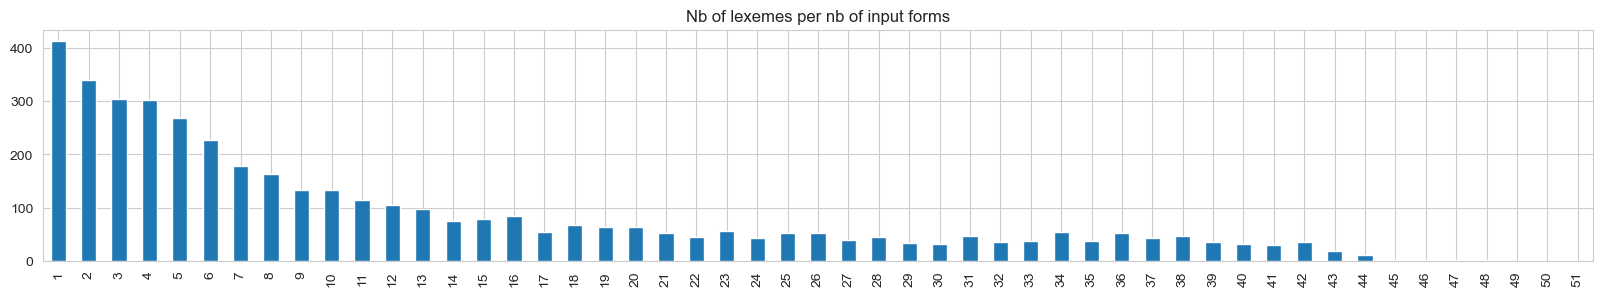

In [56]:
# print("input",dfInput4.count().sort_index().sum())
sInput4=dfInput4.T.count().value_counts()
for n in range(1,52):
    if n not in sInput4.index:
        sInput4[n]=0
sInput4.sort_index(inplace=True)
sInput4.plot(kind="bar",figsize=(20,3),title="Nb of lexemes per nb of input forms")
plt.show()
# sInput4

### Platinum

In [57]:
fTotal=repFiles+"vlexique2-Total.csv"
dfTotal=pd.read_csv(fTotal,sep=";")
dfTotal.set_index("lexeme",inplace=True)
dfTotal=dfTotal.loc[dfTotal.index.isin(ixInput4)]
dfTest4=dfTotal.compare(dfInput4,keep_shape=True).loc[:,(slice(None),"self")]
dfTest4.columns=dfTest4.columns.get_level_values(0)
dfTest4

,ai1P,ai1S,ai2P,ai2S,ai3P,ai3S,fi1P,fi1S,fi2P,fi2S,...,ppFP,ppFS,ppMP,ppMS,ps1P,ps1S,ps2P,ps2S,ps3P,ps3S
lexeme,,,,,,,,,,,,,,,,,,,,,
abaisser,abEsam,abEsE,abEsat,abEsa,abEsEr,abEsa,abEs6rô,NaN,abEs6re,abEs6ra,...,NaN,NaN,NaN,NaN,abEsjô,NaN,abEsje,NaN,abEs,NaN
abandonner,abâdOnam,NaN,abâdOnat,abâdOna,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
abasourdir,abazurdim,abazurdi,abazurdit,abazurdi,abazurdir,abazurdi,abazurdirô,abazurdirE,abazurdire,abazurdira,...,abazurdi,NaN,NaN,NaN,abazurdisjô,abazurdis,abazurdisje,abazurdis,abazurdis,abazurdis
abattre,abatim,abati,abatit,abati,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,abatjô,NaN,NaN,NaN,NaN,NaN
abdiquer,abdikam,abdikE,abdikat,abdika,abdikEr,abdika,abdik6rô,abdik6rE,abdik6re,abdik6ra,...,abdike,abdike,abdike,NaN,abdikjô,abdik,abdikje,abdik,abdik,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
éviscérer,EvisEram,EvisErE,EvisErat,EvisEra,EvisErEr,EvisEra,EvisEr6rô,EvisEr6rE,EvisEr6re,EvisEr6ra,...,EvisEre,NaN,NaN,NaN,EvisErjô,EvisEr,EvisErje,EvisEr,EvisEr,EvisEr
éviter,Evitam,EvitE,Evitat,Evita,EvitEr,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
évoluer,EvOlHam,EvOlHE,EvOlHat,EvOlHa,EvOlHEr,NaN,EvOlyrô,EvOlyrE,EvOlyre,NaN,...,NaN,NaN,NaN,NaN,EvOlyjô,EvOly,EvOlyje,EvOly,NaN,NaN


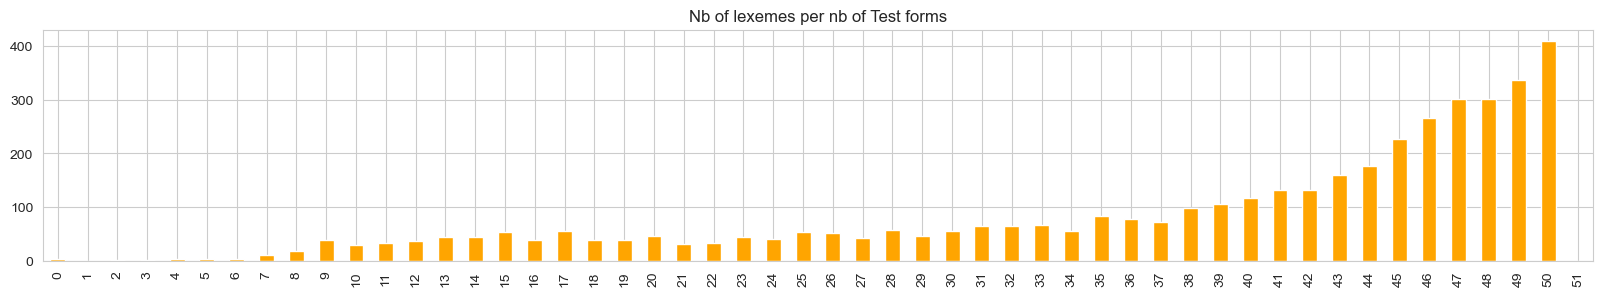

In [58]:
# print("Test",dfTest4.count().sort_index().sum())
sTest4=dfTest4.T.count().value_counts()
for n in range(1,52):
    if n not in sTest4.index:
        sTest4[n]=0
sTest4.sort_index(inplace=True)
sTest4.plot(kind="bar",figsize=(20,3),color="orange",title="Nb of lexemes per nb of Test forms")
plt.show()

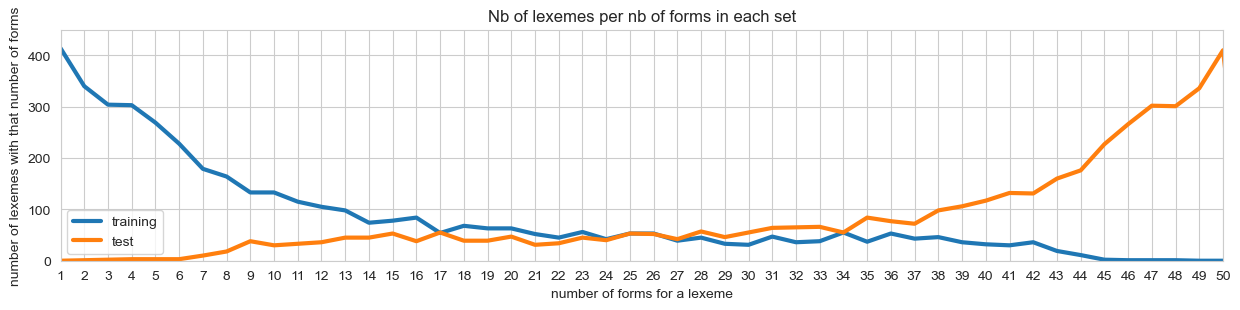

In [59]:
ax=pd.DataFrame({"training":sInput4,"test":sTest4}).plot(kind="line",linewidth=3,figsize=(15,3),title="Nb of lexemes per nb of forms in each set")
ax.set_xlim(1,50)
ax.set_xlabel("number of forms for a lexeme")
ax.set_ylim(0,450)
ax.set_ylabel("number of lexemes with that number of forms")
ax.set_xticks(range(1,51))
plt.savefig("temp.png",dpi=300,bbox_inches="tight")

In [60]:
cComplete4=dfComplete4[cellOrd].count()
cInput4=dfInput4[cellOrd].count()
dfRemplissage4=pd.DataFrame({"input":cInput4,"complete":cComplete4})
dfRemplissage4["proportion"]=dfRemplissage4.input.astype(str)+"/"+dfRemplissage4.complete.astype(str)
dfRemplissage4["pourcentage"]=dfRemplissage4.input/dfRemplissage4.complete*100
dRemplissage4Prop=dfRemplissage4["proportion"].to_dict()
dRemplissage4Perc=dfRemplissage4["pourcentage"].to_dict()

In [61]:
def getTable(fName):
    df=pd.read_csv(fName,sep=";")
    if "Unnamed: 0" in df.columns:
        df.set_index("Unnamed: 0",inplace=True)
        df.index.rename("lexeme",inplace=True)
    elif "lexeme" in df.columns:
        df.set_index("lexeme",inplace=True)
    for c in cellOrd:
        if c not in df.columns:
            df[c]=np.NaN
    return df[cellOrd]

<Axes: title={'center': 'Direct correct/different'}>

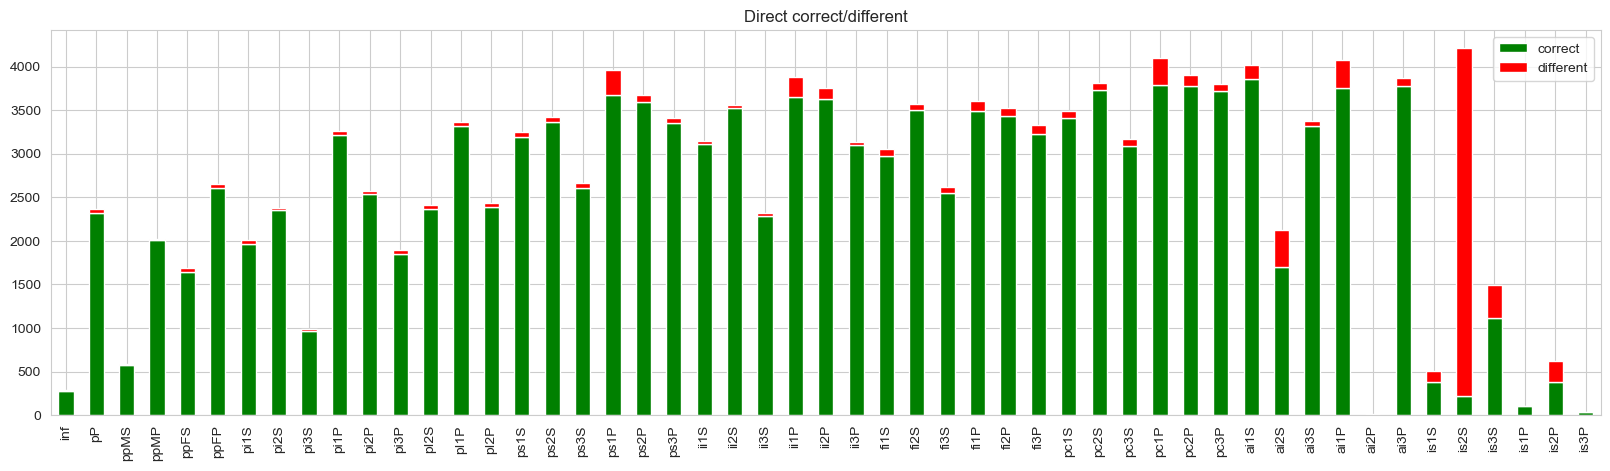

In [40]:
fDirect4Diff=repFiles+"vlexique2-Direct-S4-omp-platinum-different.csv"
fDirect4Corr=repFiles+"vlexique2-Direct-S4-omp-platinum-correct.csv"

dfDirect4Diff=getTable(fDirect4Diff)
dfDirect4Corr=getTable(fDirect4Corr)
dfDirect4CorrDiff=pd.DataFrame({"correct":dfDirect4Corr.count(),"different":dfDirect4Diff.count()})
dfDirect4CorrDiff.reindex(cellOrd).plot.bar(stacked=True,figsize=(20,5),color=["green","red"],title="Direct correct/different")
    # 

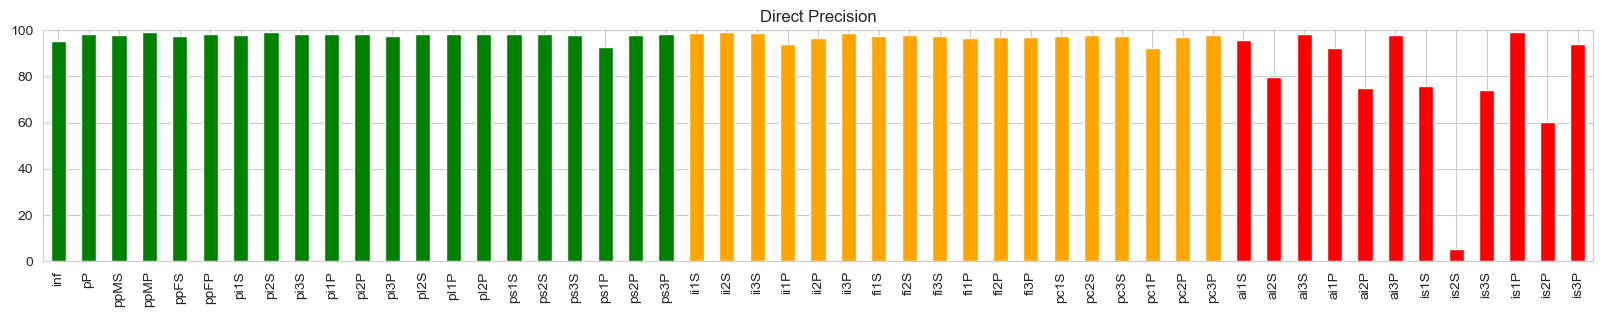

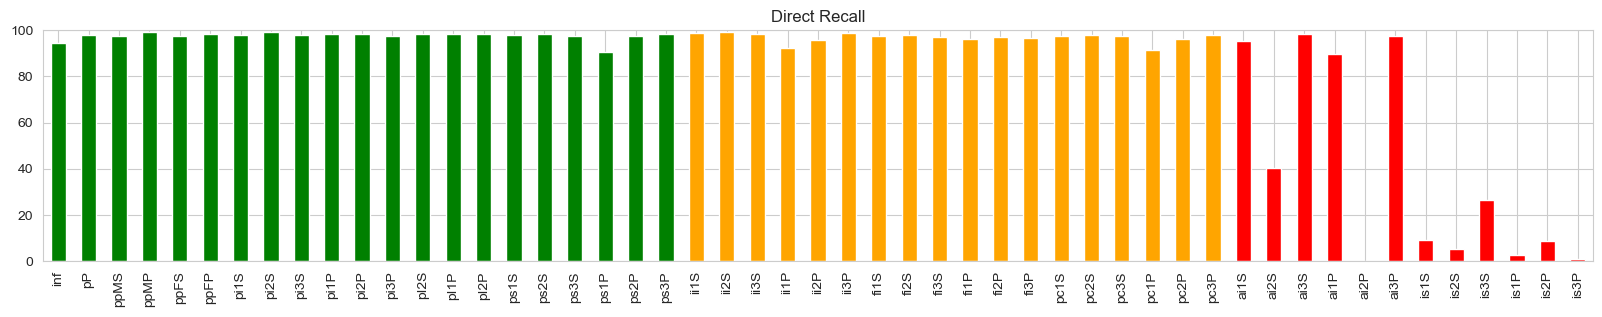

(0.0, 100.0)

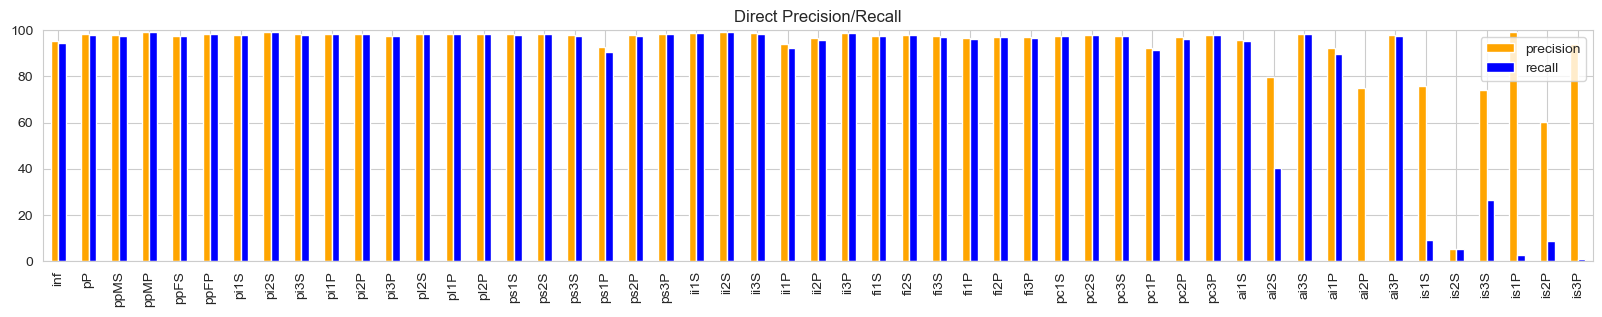

In [43]:
fDirect4Diff=repFiles+"vlexique2-Direct-S4-omp-platinum-different.csv"
fDirect4Corr=repFiles+"vlexique2-Direct-S4-omp-platinum-correct.csv"
fDirect4Miss=repFiles+"vlexique2-Direct-S4-omp-platinum-missing.csv"

dfDirect4Diff=getTable(fDirect4Diff)
sDirect4Diff=dfDirect4Diff.count()
dfDirect4Corr=getTable(fDirect4Corr)
sDirect4Corr=dfDirect4Corr.count()
dfDirect4Miss=getTable(fDirect4Miss)
sDirect4Miss=dfDirect4Miss.count()

dfDirect4Precision=sDirect4Corr/(sDirect4Corr+sDirect4Diff)*100
ax=dfDirect4Precision.plot(kind="bar",color=cellColor,figsize=(20,3),title="Direct Precision") 
ax.set_ylim(00,100)
plt.show()

dfDirect4Recall=sDirect4Corr/(sDirect4Corr+sDirect4Diff+sDirect4Miss)*100
ax=dfDirect4Recall.plot(kind="bar",color=cellColor,figsize=(20,3),title="Direct Recall") 
ax.set_ylim(00,100)
plt.show()

ax=pd.DataFrame({"precision":dfDirect4Precision,"recall":dfDirect4Recall}).plot(kind="bar",
                                                                             color=["orange","blue"],
                                                                             figsize=(20,3),title="Direct Precision/Recall") 
ax.set_ylim(0,100)


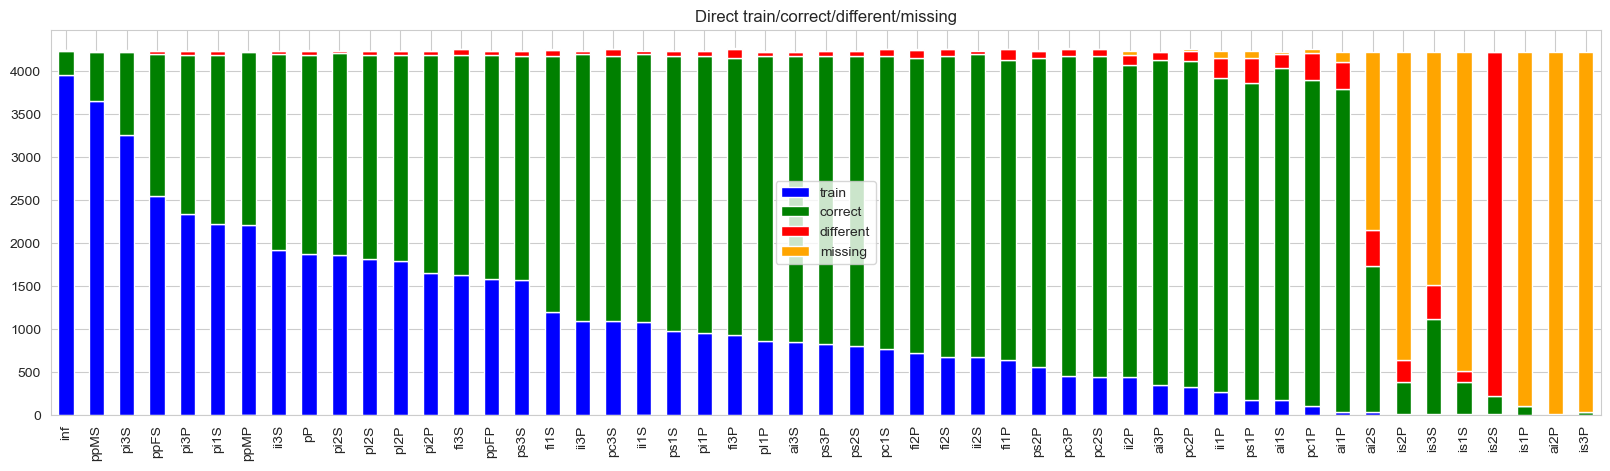

In [49]:
dfDirect4Dist=pd.DataFrame({"train":dfInput4.count(),"correct":dfDirect4Corr.count(),"different":dfDirect4Diff.count(),"missing":dfDirect4Miss.count()})
dfDirect4Dist.sort_values("train",inplace=True,ascending=False)
dfDirect4Dist.plot.bar(stacked=True,figsize=(20,5),color=["blue","green","red","orange"],title="Direct train/correct/different/missing")
plt.savefig(repFiles+"Distribution-Direct-Platinum.png",dpi=300)

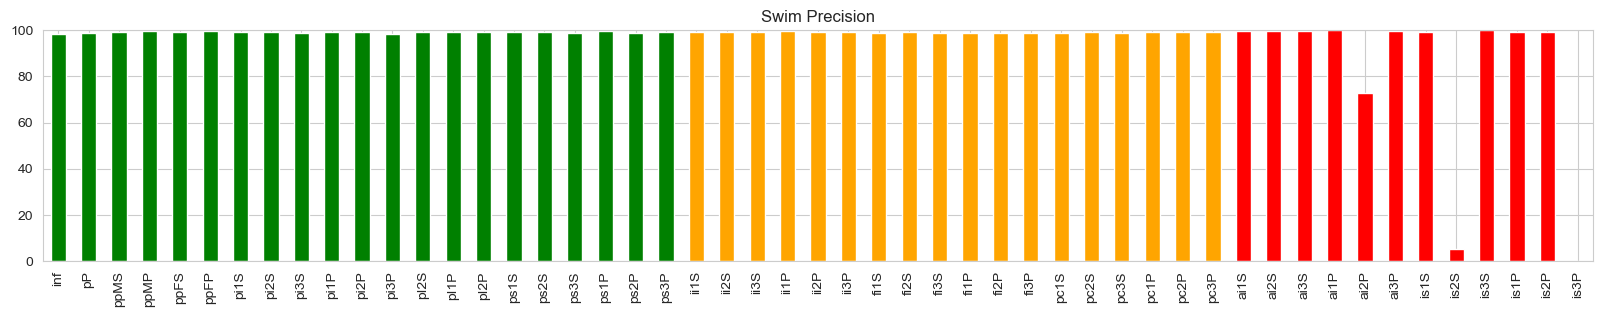

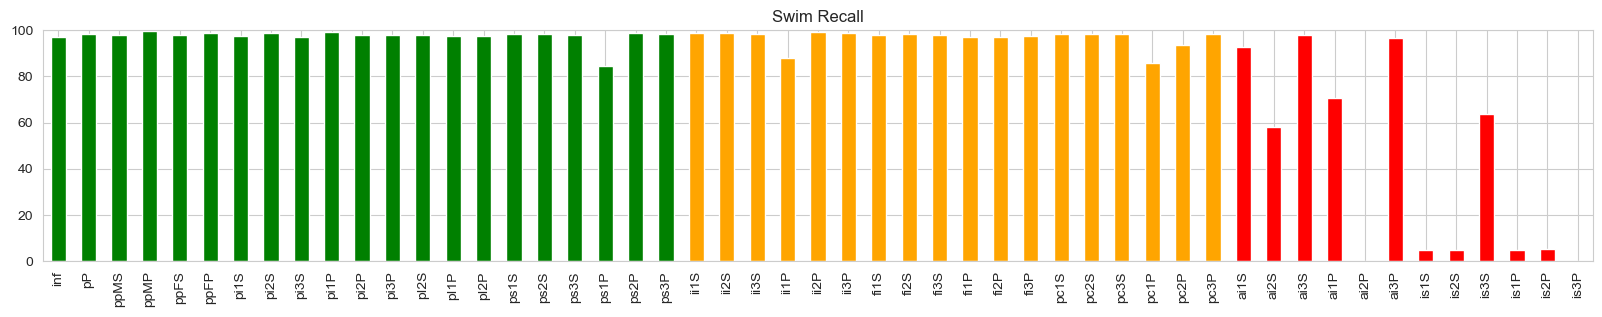

(0.0, 100.0)

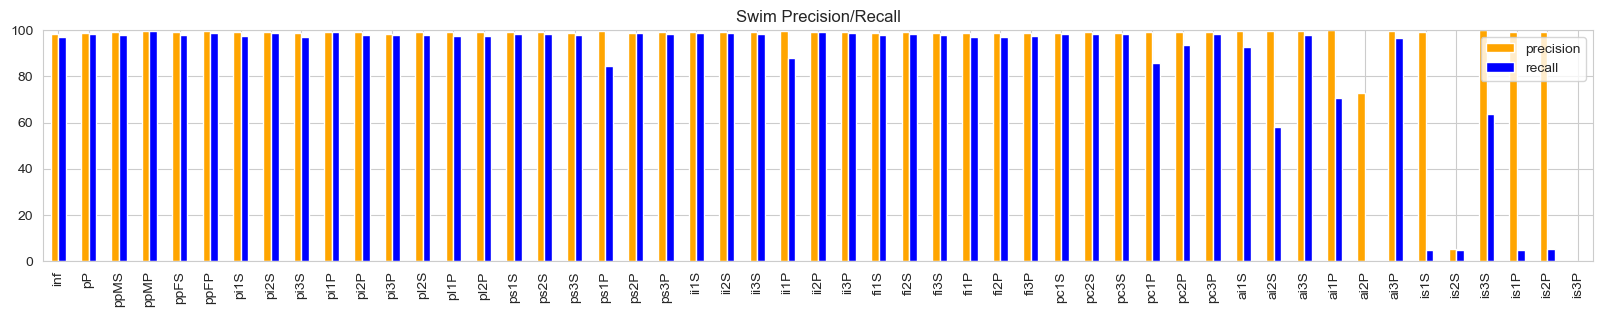

In [46]:
fSwim4Diff=repFiles+"vlexique2-S4-StemSpace-platinum-different.csv"
fSwim4Corr=repFiles+"vlexique2-S4-StemSpace-platinum-correct.csv"
fSwim4Miss=repFiles+"vlexique2-S4-StemSpace-platinum-missing.csv"

dfSwim4Diff=getTable(fSwim4Diff)
sSwim4Diff=dfSwim4Diff.count()
dfSwim4Corr=getTable(fSwim4Corr)
sSwim4Corr=dfSwim4Corr.count()
dfSwim4Miss=getTable(fSwim4Miss)
sSwim4Miss=dfSwim4Miss.count()

dfSwim4Precision=sSwim4Corr/(sSwim4Corr+sSwim4Diff)*100
ax=dfSwim4Precision.plot(kind="bar",color=cellColor,figsize=(20,3),title="Swim Precision") 
ax.set_ylim(0,100)
plt.show()

dfSwim4Recall=sSwim4Corr/(sSwim4Corr+sSwim4Diff+sSwim4Miss)*100
ax=dfSwim4Recall.plot(kind="bar",color=cellColor,figsize=(20,3),title="Swim Recall") 
ax.set_ylim(0,100)
plt.show()

ax=pd.DataFrame({"precision":dfSwim4Precision,"recall":dfSwim4Recall}).plot(kind="bar",
                                                                             color=["orange","blue"],
                                                                             figsize=(20,3),title="Swim Precision/Recall") 
ax.set_ylim(0,100)


<Axes: title={'center': 'Swim correct/different'}>

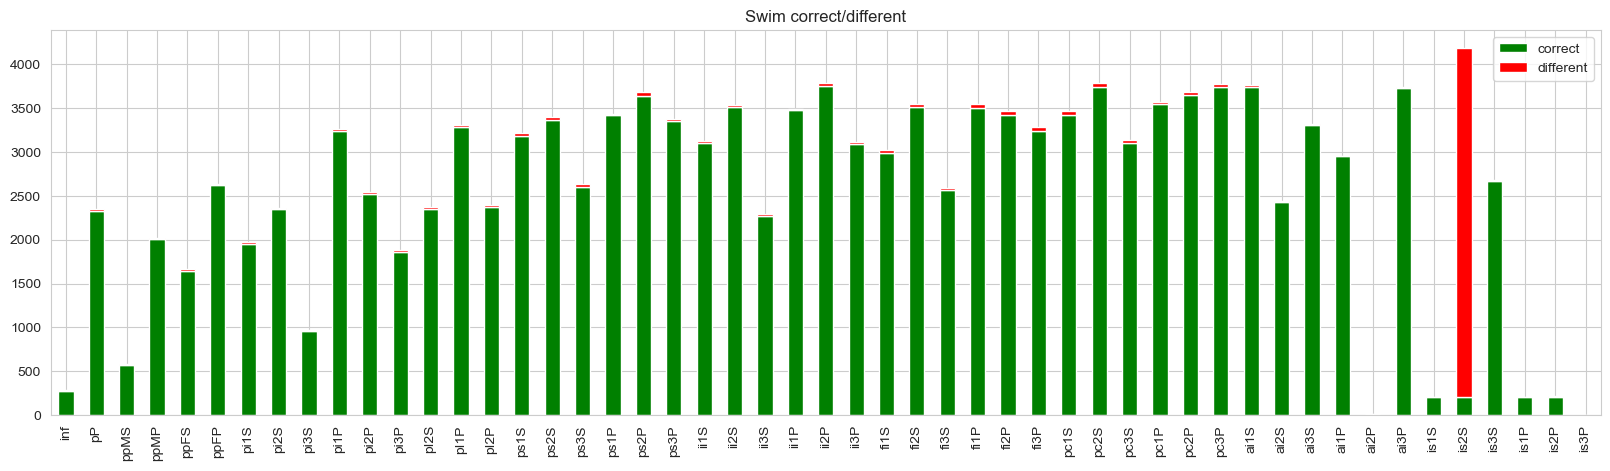

In [47]:

dfSwim4CorrDiff=pd.DataFrame({"correct":dfSwim4Corr.count(),"different":dfSwim4Diff.count()})
dfSwim4CorrDiff.reindex(cellOrd).plot.bar(stacked=True,figsize=(20,5),color=["green","red"],title="Swim correct/different")
    # 

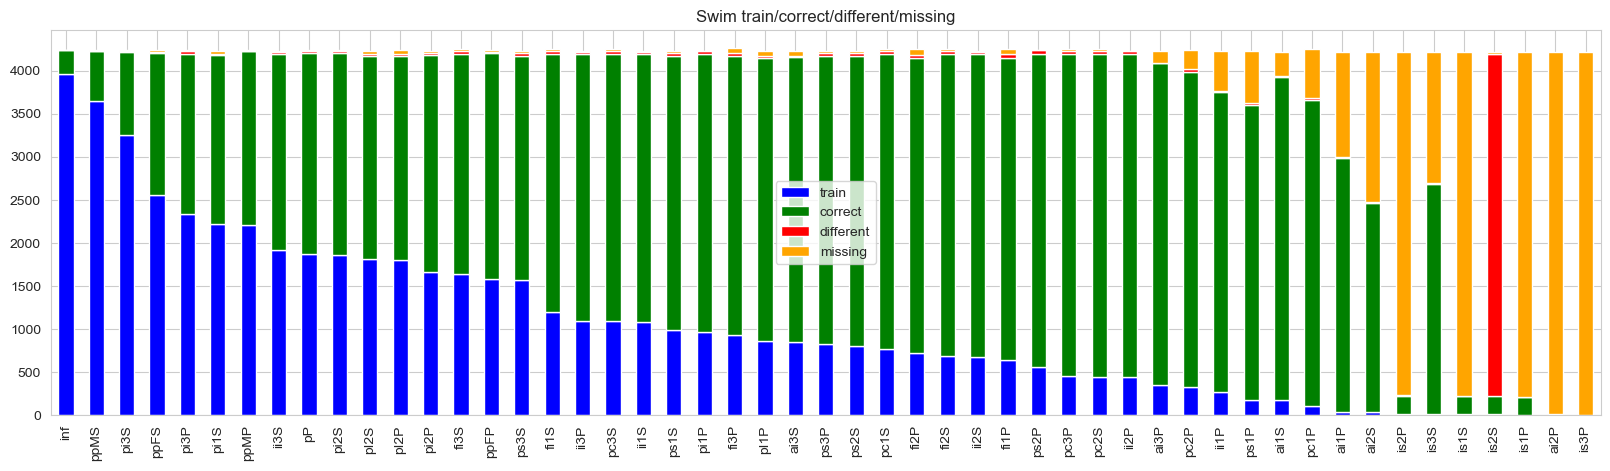

In [48]:
dfSwim4Dist=pd.DataFrame({"train":dfInput4.count(),"correct":dfSwim4Corr.count(),"different":dfSwim4Diff.count(),"missing":dfSwim4Miss.count()})
dfSwim4Dist.sort_values("train",inplace=True,ascending=False)
dfSwim4Dist.plot.bar(stacked=True,figsize=(20,5),color=["blue","green","red","orange"],title="Swim train/correct/different/missing")
plt.savefig(repFiles+"Distribution-Swim-Platinum.png",dpi=300)

### Analyse par nombre de formes

In [81]:
dfDirect4Verbs=pd.DataFrame({"known":dfInput4.T.count(),
                             "correct":dfDirect4Corr.T.count(),
                             "wrong":dfDirect4Diff.T.count(),
                             "missing":dfDirect4Miss.T.count()})
dfDirect4Verbs["errors"]=dfDirect4Verbs.wrong+dfDirect4Verbs.missing

In [88]:
dfDirect4VerbsNbSum=dfDirect4Verbs.groupby("known").sum()
dfDirect4VerbsNbSum.iloc[41:].sum()

correct    162
wrong      152
missing    267
errors     419
dtype: int64

In [82]:
dfDirect4VerbsNb=dfDirect4Verbs.groupby("known").mean()
dfDirect4VerbsNb.iloc[:41]

,correct,wrong,missing,errors
known,,,,
1,40.442029,2.171498,6.942029,9.113527
2,40.188235,1.991176,6.529412,8.520588
3,39.338816,2.407895,6.368421,8.776316
4,38.534653,2.079208,6.330033,8.409241
5,37.933086,1.914498,6.226766,8.141264
6,36.925439,2.105263,6.105263,8.210526
7,35.670391,1.882682,6.106145,7.988827
8,34.304878,2.140244,6.146341,8.286585
9,33.992481,1.661654,5.909774,7.571429


In [84]:
dfDirect4VerbsNb["pCorrect"]=round(dfDirect4VerbsNb.correct/(dfDirect4VerbsNb.correct+dfDirect4VerbsNb.errors)*100,1)
dfDirect4VerbsNb["pErrors"]=round(dfDirect4VerbsNb.errors/(dfDirect4VerbsNb.correct+dfDirect4VerbsNb.errors)*100,1)
dfDirect4VerbsNb

,correct,wrong,missing,errors,pCorrect,pErrors
known,,,,,,
1,40.442029,2.171498,6.942029,9.113527,81.6,18.4
2,40.188235,1.991176,6.529412,8.520588,82.5,17.5
3,39.338816,2.407895,6.368421,8.776316,81.8,18.2
4,38.534653,2.079208,6.330033,8.409241,82.1,17.9
5,37.933086,1.914498,6.226766,8.141264,82.3,17.7
6,36.925439,2.105263,6.105263,8.210526,81.8,18.2
7,35.670391,1.882682,6.106145,7.988827,81.7,18.3
8,34.304878,2.140244,6.146341,8.286585,80.5,19.5
9,33.992481,1.661654,5.909774,7.571429,81.8,18.2


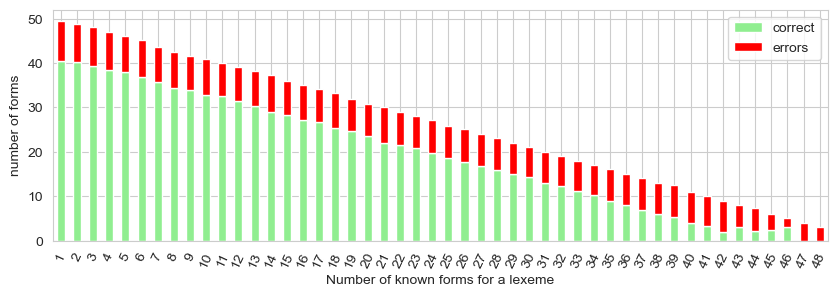

In [79]:
ax=dfDirect4VerbsNb[:51][["correct","errors"]].plot.bar(stacked=True, figsize=(10,3),
                                                                       color=["lightgreen", "red", "orange"])
# labels=["known","correct","errors"]
# plt.legend(labels);
ax.set_xlabel("Number of known forms for a lexeme")
ax.set_ylabel("number of forms")
ax.tick_params(axis='x', labelrotation=65)
ax.set_xlim(-0.5,47.5)

plt.savefig(repFiles+"Distribution-Direct-Platinum-NbForms.png",dpi=300,bbox_inches="tight")

## Tables Précision/Rappel

In [96]:
def makeTabular(dictColours,title="",coulLim=False, cat="V", typeNum="float"):
    tabular=[]
    def makeLine6(tenseCode):
        line=[tenseCode]
        for person in [per+nb for nb in ["S","P"] for per in ["1","2","3"]]:
            case=tenseCode+person
            if case in dictColours:
                if typeNum=="float":
                    line.append("%.1f"%dictColours[case])
                elif typeNum=="string":
                    line.append(dictColours[case])
                else:
                    line.append("%d"%dictColours[case])
            else:
                line.append(" ")
        return r" & ".join(line)+r"\\"

    def makeLine3(tenseCode):
        line=[tenseCode]
        for person in [per+nb for nb in ["S","P"] for per in ["1","2","3"]]:
            if person in ["2S","1P","2P"]:
                case=tenseCode+person
                if case in dictColours:
                    if typeNum=="float":
                        line.append("%.1f"%dictColours[case])
                    elif typeNum=="string":
                        line.append(dictColours[case])
                    else:
                        line.append("%d"%dictColours[case])                    
                else:
                    line.append(" ")
#                line.append(r"\cellcolor{%s}%s"%(dictColours[case],case))
            else:
                line.append(r"---")
        return r" & ".join(line)+r"\\"
    
    def makeLineNF():
        line=[" "]
        for case in ["inf","pP","ppMS","ppMP","ppFS","ppFP"]:
            if case in dictColours:
                if typeNum=="float":
                    line.append("%.1f"%dictColours[case])
                elif typeNum=="string":
                    line.append(dictColours[case])
                else:
                    line.append("%d"%dictColours[case])
            else:
                line.append(" ")
#            line.append(r"\cellcolor{%s}%s"%(dictColours[case],case))
        return r" & ".join(line)+r"\\"

    def makeLineMF(nombre):
        line=[]
        for genre in "mf":
            case=genre+nombre
            if case in dictColours:
                if typeNum=="float":
                    line.append("%.1f"%dictColours[case])
                elif typeNum=="string":
                    line.append(dictColours[case])
                else:
                    line.append("%d"%dictColours[case])                
            # else:
            #     line.append(r"\cellcolor{%s}%s"%("black",case))
        return r" & ".join(line)+r"\\"
    
    def makeLineCoulLim():
        line=[]
        for numLimite,limite in enumerate(listLimites):
            line.append(r"\cellcolor{%s}%s"%(listLimCoul[numLimite],"$<$"+str(limite)))
        return r"\hline\hline "+r" & ".join(line)+r"\\"
        
    if cat=="V":
        top=[
            r"\begin{center}",
            r"\begin{tabular}{rcccccc}",
            r"&1S&2S&3S&1P&2P&3P\\",
            r"\hline"
            ]
        bottom=[
            r"\hline",
            r"\end{tabular}\\",
            title,
            r"\end{center}",
            r"\bigskip",
            r""
            ]
        tabular.append("\n".join(top))
        for tenseCode in ["pi","ii","fi","pc", "ps","ai", "is"]:
            tabular.append(makeLine6(tenseCode))
        tabular.append(makeLine3("pI"))
        tabular.append(r"\hline")
        tabular.append(r"&inf & pP & ppMS &ppMP&ppFS&ppFP\\")
        tabular.append(makeLineNF())
    elif cat=="A":
        top=[
            r"\begin{center}",
            r"\begin{tabular}{cc}",
            r"\hline"
            ]
        bottom=[
            r"\hline",
            r"\end{tabular}\\",
            title,
            r"\end{center}",
            r"\bigskip",
            r""
            ]
        tabular.append("\n".join(top))
        for number in "sp":
            tabular.append(makeLineMF(number))
    if coulLim:
        tabular.append(makeLineCoulLim())
    tabular.append("\n".join(bottom))
    return "\n".join(tabular)

In [100]:
print(makeTabular(dRemplissage4Prop,title="Train/Total",typeNum="string"))
print()
print(makeTabular(dRemplissage4Perc,title="Train/Total"))
print()

\begin{center}
\begin{tabular}{rcccccc}
&1S&2S&3S&1P&2P&3P\\
\hline
pi & 2223/3602 & 1859/3332 & 3254/4050 & 960/2335 & 1657/3215 & 2336/3669\\
ii & 1083/2560 & 674/2010 & 1915/3420 & 274/1062 & 443/1532 & 1097/2689\\
fi & 1197/2662 & 681/1941 & 1634/3130 & 643/1794 & 720/1972 & 926/2375\\
pc & 765/2099 & 447/1513 & 1090/2575 & 110/632 & 332/1223 & 454/1652\\
ps & 983/2494 & 804/2177 & 1569/3179 & 181/882 & 554/1673 & 822/2262\\
ai & 181/865 & 31/262 & 845/2243 & 35/318 & 3/59 & 354/1460\\
is & 10/86 & 10/57 & 13/243 & 3/41 & 15/81 & 2/52\\
pI & --- & 1818/3287 & --- & 862/2219 & 1796/3279 & ---\\
\hline
&inf & pP & ppMS &ppMP&ppFS&ppFP\\
  & 3955/4208 & 1875/3418 & 3648/4167 & 2212/3443 & 2551/3541 & 1579/3011\\
\hline
\end{tabular}\\
Train/Total
\end{center}
\bigskip


\begin{center}
\begin{tabular}{rcccccc}
&1S&2S&3S&1P&2P&3P\\
\hline
pi & 61.7 & 55.8 & 80.3 & 41.1 & 51.5 & 63.7\\
ii & 42.3 & 33.5 & 56.0 & 25.8 & 28.9 & 40.8\\
fi & 45.0 & 35.1 & 52.2 & 35.8 & 36.5 & 39.0\\
pc & 36.4

In [105]:
dictPrecisionCellsDirect=dfDirect4Precision.to_dict()
print(makeTabular(dictPrecisionCellsDirect,title="Direct Precision",coulLim=False, cat="V"))
print()

dictRecallCellsDirect=dfDirect4Recall.to_dict()
print(makeTabular(dictRecallCellsDirect,title="Direct Recall",coulLim=False, cat="V"))
print()


\begin{center}
\begin{tabular}{rcccccc}
&1S&2S&3S&1P&2P&3P\\
\hline
pi & 98.3 & 99.6 & 98.9 & 99.1 & 99.1 & 98.3\\
ii & 99.5 & 99.7 & 99.1 & 97.8 & 99.0 & 99.5\\
fi & 98.2 & 98.3 & 97.8 & 96.5 & 97.5 & 97.4\\
pc & 99.0 & 98.8 & 98.4 & 92.3 & 97.3 & 99.0\\
ps & 99.2 & 99.1 & 98.1 & 95.0 & 98.8 & 99.0\\
ai & 92.8 & 68.4 & 98.4 & 80.6 & 100.0 & 96.5\\
is & 95.2 & 80.9 & 51.3 & 100.0 & 98.3 & 80.0\\
pI & --- & 98.6 & --- & 99.3 & 99.2 & ---\\
\hline
&inf & pP & ppMS &ppMP&ppFS&ppFP\\
  & 95.2 & 98.4 & 98.3 & 99.8 & 98.0 & 98.9\\
\hline
\end{tabular}\\
Direct Precision
\end{center}
\bigskip


\begin{center}
\begin{tabular}{rcccccc}
&1S&2S&3S&1P&2P&3P\\
\hline
pi & 98.3 & 99.6 & 98.7 & 99.1 & 99.1 & 98.3\\
ii & 99.5 & 99.7 & 99.0 & 97.7 & 98.9 & 99.4\\
fi & 98.2 & 98.3 & 97.7 & 96.3 & 97.4 & 97.1\\
pc & 99.0 & 98.7 & 98.3 & 92.2 & 97.3 & 99.0\\
ps & 99.2 & 99.1 & 98.1 & 95.0 & 98.6 & 99.0\\
ai & 92.8 & 63.6 & 98.4 & 80.3 & 1.8 & 96.4\\
is & 77.6 & 80.9 & 42.2 & 39.5 & 89.4 & 8.0\\
pI & --- &

In [106]:
dictPrecisionCellsSwim=dfSwim4Precision.to_dict()
print(makeTabular(dictPrecisionCellsSwim,title="Swim Precision",coulLim=False, cat="V"))
print()

dictRecallCellsSwim=dfSwim4Recall.to_dict()
print(makeTabular(dictRecallCellsSwim,title="Swim Recall",coulLim=False, cat="V"))
print()


\begin{center}
\begin{tabular}{rcccccc}
&1S&2S&3S&1P&2P&3P\\
\hline
pi & 99.6 & 99.7 & 98.7 & 99.7 & 99.8 & 99.1\\
ii & 99.9 & 99.9 & 99.6 & 100.0 & 99.9 & 99.9\\
fi & 99.5 & 99.8 & 99.3 & 99.6 & 99.5 & 99.5\\
pc & 99.7 & 99.5 & 99.7 & 100.0 & 100.0 & 99.7\\
ps & 99.8 & 99.6 & 99.4 & 100.0 & 99.6 & 99.6\\
ai & 99.8 & 100.0 & 99.8 & 99.4 & nan & 99.9\\
is & 100.0 & 78.7 & 100.0 & 100.0 & 100.0 & nan\\
pI & --- & 99.5 & --- & 99.7 & 99.7 & ---\\
\hline
&inf & pP & ppMS &ppMP&ppFS&ppFP\\
  & 98.0 & 99.3 & 99.2 & 99.8 & 99.6 & 99.8\\
\hline
\end{tabular}\\
Swim Precision
\end{center}
\bigskip


\begin{center}
\begin{tabular}{rcccccc}
&1S&2S&3S&1P&2P&3P\\
\hline
pi & 97.8 & 99.4 & 97.7 & 99.6 & 98.6 & 98.7\\
ii & 99.3 & 99.6 & 98.9 & 90.0 & 99.8 & 99.4\\
fi & 99.0 & 99.2 & 98.2 & 96.5 & 96.7 & 97.2\\
pc & 99.3 & 99.4 & 98.9 & 82.4 & 92.7 & 99.5\\
ps & 99.1 & 99.2 & 98.3 & 86.7 & 99.4 & 98.8\\
ai & 88.6 & 47.2 & 97.3 & 61.3 & 0.0 & 93.8\\
is & 64.5 & 78.7 & 47.8 & 81.6 & 80.3 & 0.0\\
pI & --

In [129]:
dfCompPrecision=pd.DataFrame({"direct":dictPrecisionCellsDirect,"swim":dictPrecisionCellsSwim})
dfCompPrecision["percentage"]=dfCompPrecision.direct.round(1).astype(str)+" | "+dfCompPrecision.swim.round(1).astype(str)
dictCompPrecision=dfCompPrecision.percentage.to_dict()

print(makeTabular(dictCompPrecision,title="Precision Direct | Swim",coulLim=False, cat="V", typeNum="string"))
print()

dfCompRecall=pd.DataFrame({"direct":dictRecallCellsDirect,"swim":dictRecallCellsSwim})
dfCompRecall["percentage"]=dfCompRecall.direct.round(1).astype(str)+" | "+dfCompRecall.swim.round(1).astype(str)
dictCompRecall=dfCompRecall.percentage.to_dict()

print(makeTabular(dictCompRecall,title="Recall Direct | Swim",coulLim=False, cat="V", typeNum="string"))
print()


\begin{center}
\begin{tabular}{rcccccc}
&1S&2S&3S&1P&2P&3P\\
\hline
pi & 98.3 | 99.6 & 99.6 | 99.7 & 98.9 | 98.7 & 99.1 | 99.7 & 99.1 | 99.8 & 98.3 | 99.1\\
ii & 99.5 | 99.9 & 99.7 | 99.9 & 99.1 | 99.6 & 97.8 | 100.0 & 99.0 | 99.9 & 99.5 | 99.9\\
fi & 98.2 | 99.5 & 98.3 | 99.8 & 97.8 | 99.3 & 96.5 | 99.6 & 97.5 | 99.5 & 97.4 | 99.5\\
pc & 99.0 | 99.7 & 98.8 | 99.5 & 98.4 | 99.7 & 92.3 | 100.0 & 97.3 | 100.0 & 99.0 | 99.7\\
ps & 99.2 | 99.8 & 99.1 | 99.6 & 98.1 | 99.4 & 95.0 | 100.0 & 98.8 | 99.6 & 99.0 | 99.6\\
ai & 92.8 | 99.8 & 68.4 | 100.0 & 98.4 | 99.8 & 80.6 | 99.4 & 100.0 | nan & 96.5 | 99.9\\
is & 95.2 | 100.0 & 80.9 | 78.7 & 51.3 | 100.0 & 100.0 | 100.0 & 98.3 | 100.0 & 80.0 | nan\\
pI & --- & 98.6 | 99.5 & --- & 99.3 | 99.7 & 99.2 | 99.7 & ---\\
\hline
&inf & pP & ppMS &ppMP&ppFS&ppFP\\
  & 95.2 | 98.0 & 98.4 | 99.3 & 98.3 | 99.2 & 99.8 | 99.8 & 98.0 | 99.6 & 98.9 | 99.8\\
\hline
\end{tabular}\\
Precision Direct | Swim
\end{center}
\bigskip


\begin{center}
\begin{tabular}{rcc

# Corrélations

In [209]:
print("dataset",dfComplete4.count().corr(dfSwim4Precision))
print("train",dfInput4.count().corr(dfSwim4Precision))
print("test",(dfComplete4.count()-dfInput4.count()).corr(dfSwim4Precision))
print("test/train",((dfComplete4.count()-dfInput4.count())/dfInput4.count()).corr(dfSwim4Precision))

dataset 0.17839285850486417
train 0.07203141042204453
test 0.29461080585568417
test/train -0.04338254986019139


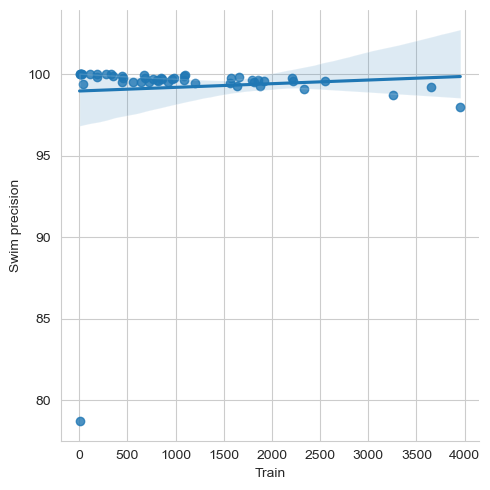

In [206]:
dfLocal=dfComplete4.count()-dfInput4.count()
dfLocal=dfComplete4.count()
dfLocal=dfInput4.count()
dfCorrelation=pd.DataFrame({"Train":dfLocal,"Swim precision":dfSwim4Precision})

# ax=dfCorrelation.plot.scatter(x="Test",y="Swim precision")
# ax.set_ylim(97.5,100.1)
ax=sns.lmplot(x='Train',y='Swim precision',data=dfCorrelation,fit_reg=True) 
plt.savefig(repFiles+"CorrelationRL-SwimPrecision-Train.png",dpi=300)

In [249]:
condClore=(dfInput4["inf"].notnull())&(dfInput4["pi1S"].notnull())&(dfInput4["pi3S"].notnull())&\
          (dfInput4["ppMS"].notnull())&(dfInput4["ppMP"].notnull())&(dfInput4["ppFS"].notnull())&(dfInput4["ppFP"].notnull())
lClore=dfInput4.loc[condClore].T.count().loc[lambda x: x==7].index.tolist()
dfInput4[dfInput4.index.isin(lClore)]

,ai1P,ai1S,ai2P,ai2S,ai3P,ai3S,fi1P,fi1S,fi2P,fi2S,...,ppFP,ppFS,ppMP,ppMS,ps1P,ps1S,ps2P,ps2S,ps3P,ps3S
lexeme,,,,,,,,,,,,,,,,,,,,,
clore,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,kloz,kloz,klo,klo,NaN,NaN,NaN,NaN,NaN,NaN
convier,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,kôvje,kôvje,kôvje,kôvje,NaN,NaN,NaN,NaN,NaN,NaN
encastrer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,âkastre,âkastre,âkastre,âkastre,NaN,NaN,NaN,NaN,NaN,NaN
estropier,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,EstrOpje,EstrOpje,EstrOpje,EstrOpje,NaN,NaN,NaN,NaN,NaN,NaN
éditer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Edite,Edite,Edite,Edite,NaN,NaN,NaN,NaN,NaN,NaN


In [245]:
dfInput4[dfInput4.index=="clore"].T.dropna()

lexeme,clore
inf,klOr
pi1S,klo
pi3S,klo
ppFP,kloz
ppFS,kloz
ppMP,klo
ppMS,klo


In [250]:
dfInput4[dfInput4.index=="éditer"].T.dropna()

lexeme,éditer
inf,Edite
pi1S,Edit
pi3S,Edit
ppFP,Edite
ppFS,Edite
ppMP,Edite
ppMS,Edite


## Regroupements par temps et par personne

In [62]:
dfRemplissage4["tiroir"]=dfRemplissage4.index.str[:2]
dfRemplissage4["personne"]=dfRemplissage4.index.str[2:]
dfRemplissage4["test"]=dfRemplissage4.complete-dfRemplissage4.input
dfRemplissage4

,input,complete,proportion,pourcentage,tiroir,personne,test
inf,3955,4241,3955/4241,93.256307,in,f,286
pP,1875,4229,1875/4229,44.336723,pP,,2354
ppMS,3648,4235,3648/4235,86.139315,pp,MS,587
ppMP,2212,4235,2212/4235,52.231405,pp,MP,2023
ppFS,2551,4235,2551/4235,60.236128,pp,FS,1684
ppFP,1579,4235,1579/4235,37.284534,pp,FP,2656
pi1S,2223,4227,2223/4227,52.590490,pi,1S,2004
pi2S,1859,4227,1859/4227,43.979181,pi,2S,2368
pi3S,3254,4234,3254/4234,76.854039,pi,3S,980
pi1P,960,4221,960/4221,22.743426,pi,1P,3261


<Axes: title={'center': 'Platinum train/test'}, xlabel='tiroir'>

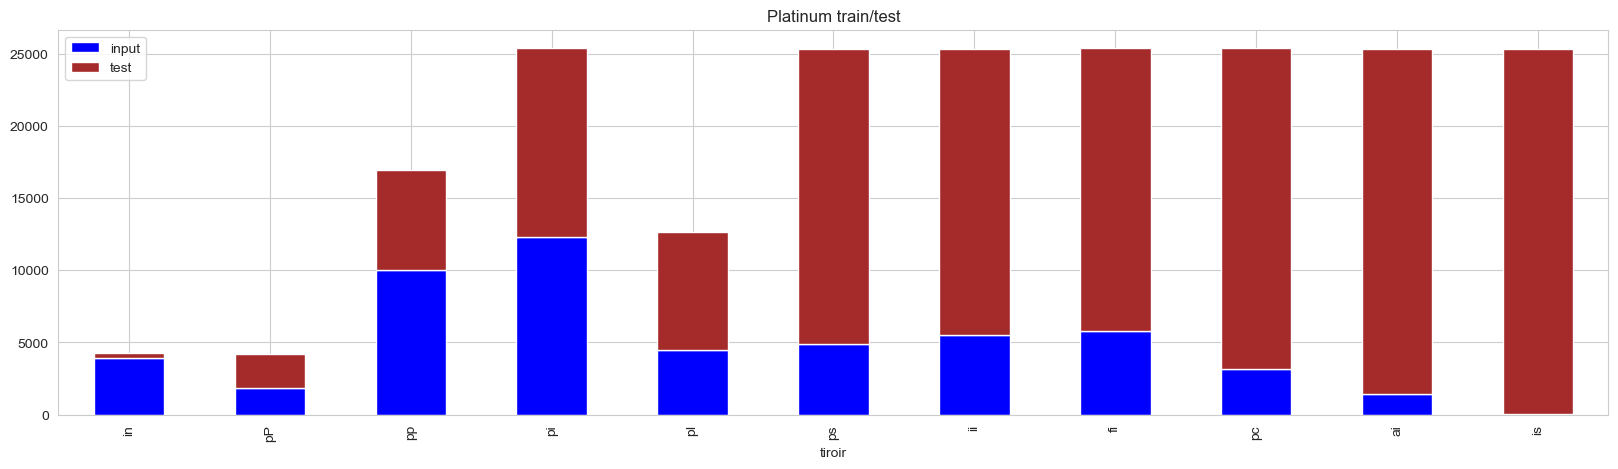

In [64]:
dfInOut4Tiroir=dfRemplissage4[["input","test","tiroir"]].groupby("tiroir").sum()
dfInOut4Tiroir=dfInOut4Tiroir.reindex(['in', 'pP', 'pp', 'pi', 'pI', 'ps', 'ii', 'fi', 'pc', 'ai', 'is'])
dfInOut4Tiroir.plot.bar(stacked=True,figsize=(20,5),color=["blue","brown"],title="Platinum train/test")

In [66]:
dfInOutPersonne=dfRemplissage4[["input","test","personne"]].groupby("personne").sum()
dfInOutPersonne.rename(index={"":"pP","f":"inf"},inplace=True)
dfInOutPersonne.reindex("inf pP MS MP FS FP 1S 2S 3S 1P 2P 3P".split())

,input,test
personne,,
inf,3955,286
pP,1875,2354
MS,3648,587
MP,2212,2023
FS,2551,1684
FP,1579,2656
1S,6442,23121
2S,6324,27463
3S,10320,19270


<Axes: title={'center': 'Platinum train/test'}, xlabel='personne'>

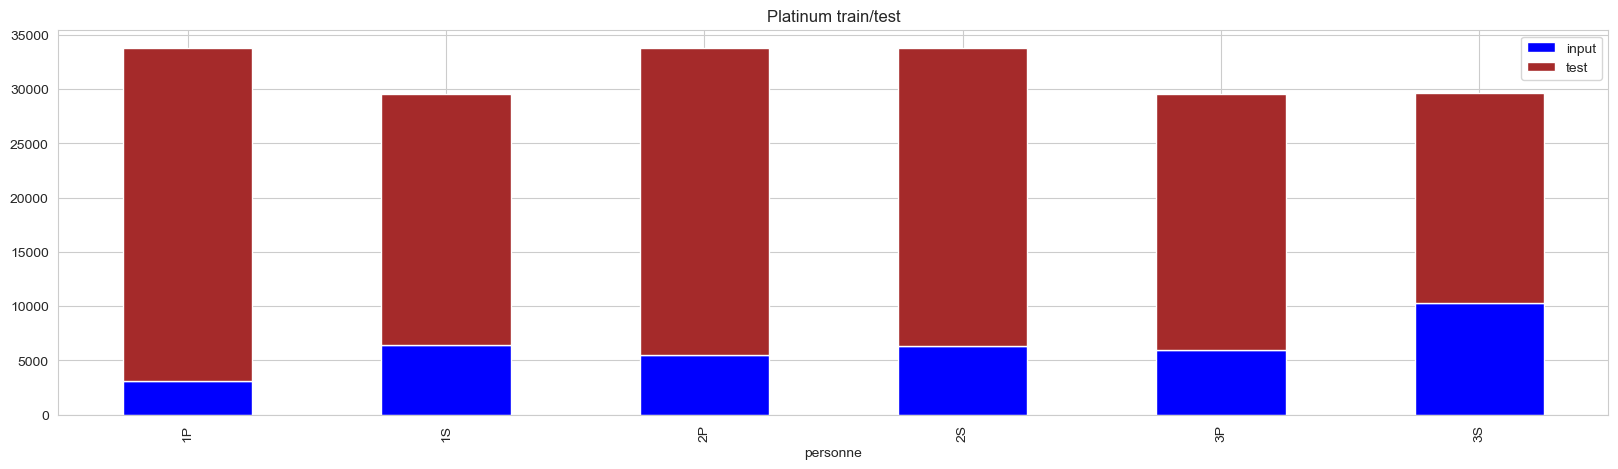

In [67]:
dfInOutPersonne[dfInOutPersonne.index.isin("1S 2S 3S 1P 2P 3P".split())].plot.bar(stacked=True,figsize=(20,5),color=["blue","brown"],title="Platinum train/test")